# Does distribution-chain fragmentation explain the gaps?

Most municipalities are served by the incumbent distributor; the rest are served by local
distribution companies, which report to the registry through their own channels. The question is
whether that second channel loses capacity on the way.

**Provenance of the treatment variable.** Which operator serves each municipality is read from the
operator registry's own field, not from the open Agence ORE mapping. Earlier versions of this
notebook attributed it to Agence ORE, which was wrong; the file is
`data/source/rte_derived/operator_by_municipality.csv` and it falls under the operator's
redistribution terms.

Three levels of analysis, in increasing order of what they can establish:

1. **Departmental, descriptive.** Relative gap against the share served by local distributors.
   Low power is expected: the incumbent serves more than 90% of municipalities almost everywhere,
   so there is little cross-sectional variation to work with.
2. **Municipal, with department fixed effects. This is the test that carries the result.** Within
   one department, do the municipalities served by a local distributor show lower registry
   coverage than those served by the incumbent?

   The identification is clean for a specific reason: the correction factor P/R is *departmental*,
   so it is constant within a department and **cancels exactly in any within-department
   comparison**. The test runs on the raw ratio of registry to detections and does not depend on
   the calibration at all. That is why it is conducted at the municipality and not at the
   reporting unit.

   Two margins: intensive, the log coverage ratio on municipalities with a registry record, and
   extensive, the probability of no registry record at all despite detected PV.
3. **By operator.** The named local distributors against the incumbent municipalities of the same
   departments. One caveat: a department served almost entirely by a single local distributor
   offers no within-department comparison of its own, and its identification comes from the fixed
   effects design rather than from itself.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

def _find_root(start, marker='paths.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(marker)

ROOT = _find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
import paths
sys.path.insert(0, str(ROOT / 'code' / '0_pipeline' / 'evaluation' / 'src'))
import style
import units
import helpers
style.apply()

FIGS_DIR = paths.FIGURES
FIG_PREFIX = 'mechanisms_eld'
PV_FLOOR_KWC = 50          # detected-PV floor for a municipality to enter the test;
                            # sensitivity at 20 and 100 is run further down

# --- Municipalities: operator, joined to the comparison table ---
cp = gpd.read_file(paths.OPERATOR_BY_MUNICIPALITY, ignore_geometry=True)
cp['insee'] = cp['insee'].astype(str).str.zfill(5)
cc = pd.read_csv(paths.COMPARISON_COMMUNES,
                 dtype={'code_insee': str, 'dpt': str})
com = cc.merge(cp[['insee', 'gestionnaire', 'categorie']],
               left_on='code_insee', right_on='insee', how='left')
com['unit'] = units.to_unit(com['dpt'])
# Distributor status. Municipalities served by several operators, or unlabelled, are excluded.
com['is_eld'] = np.where(com['categorie'] == 'Enedis', 0,
                np.where(com['categorie'] == 'Autre distributeur', 1, np.nan))
print(f"{len(com)} municipalities | local distributor: {int((com.is_eld==1).sum())} | "
      f"incumbent: {int((com.is_eld==0).sum())} | excluded: {int(com.is_eld.isna().sum())}")

# --- Units: gaps, and exposure shares recomputed from the municipalities ---
rb = pd.read_csv(paths.SPECS_RTE, dtype={'dpt': str})
rb['ecart_rel'] = (rb['p_inst_mean'] - rb['kWp_rte']) / rb['p_inst_mean']
share = (com[com.is_eld.notna()]
         .assign(pv_eld=lambda d: d.kWp_dpvm * d.is_eld)
         .groupby('unit')
         .agg(n_com=('is_eld', 'size'), share_eld_communes=('is_eld', 'mean'),
              pv_total=('kWp_dpvm', 'sum'), pv_eld=('pv_eld', 'sum')))
share['share_eld_pv'] = share['pv_eld'] / share['pv_total']   # share of DETECTED PV in ELD-served territory
dept = rb.merge(share.reset_index()[['unit', 'share_eld_communes', 'share_eld_pv']],
                left_on='dpt', right_on='unit', how='left')
dept['hard_core'] = dept['hard_core_below'] if 'hard_core_below' in dept else \
    (dept.status_A == 'below') & (dept.status_B == 'below')
print(f"exposure per unit: median {dept.share_eld_pv.median():.1%}, max {dept.share_eld_pv.max():.1%} "
      f"({dept.loc[dept.share_eld_pv.idxmax(), 'dpt']})")

34746 municipalities | local distributor: 2076 | incumbent: 31202 | excluded: 1468
exposure per unit: median 0.0%, max 100.0% (2A)


## 1. Departmental level: descriptive only

The relative gap against the **share of detected PV in ELD-served territory**. That is a better
regressor than the share of municipalities: what matters is the share of the *fleet* exposed to the
second reporting channel, not the share of the territory.

Pearson (part PV)      : r = +0.45 (p = 0.0000)
Spearman (part PV)     : rho = +0.11 (p = 0.2772)
Pearson (part communes): r = +0.44


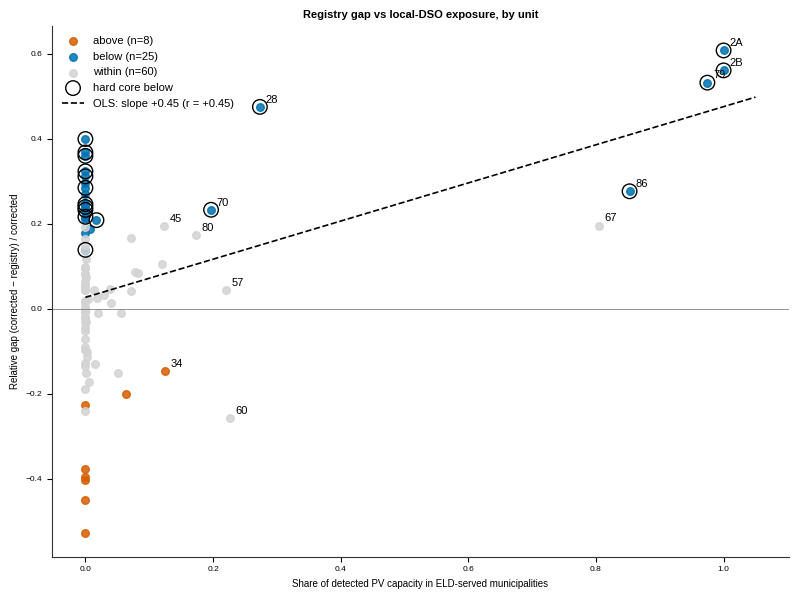

In [2]:
x = dept['share_eld_pv']
y = dept['ecart_rel']
ok = x.notna() & y.notna()
pr, pp = stats.pearsonr(x[ok], y[ok])
sr, sp = stats.spearmanr(x[ok], y[ok])
prc, _ = stats.pearsonr(dept.loc[ok, 'share_eld_communes'], y[ok])
print(f"Pearson (part PV)      : r = {pr:+.2f} (p = {pp:.4f})")
print(f"Spearman (part PV)     : rho = {sr:+.2f} (p = {sp:.4f})")
print(f"Pearson (part communes): r = {prc:+.2f}")

fig, ax = plt.subplots(figsize=(8, 6))
COL = {'below': style.OKABE_ITO['blue'], 'within': 'lightgray', 'above': style.OKABE_ITO['vermillion']}
for st, sub in dept[ok].groupby('status_A'):
    ax.scatter(sub.share_eld_pv, sub.ecart_rel, s=30, color=COL.get(st, 'gray'),
               label=f'{st} (n={len(sub)})', alpha=0.85, zorder=2)
hcm = dept[ok & dept.hard_core]
ax.scatter(hcm.share_eld_pv, hcm.ecart_rel, s=110, facecolors='none',
           edgecolors='black', linewidths=1.0, label='hard core below', zorder=3)
for _, r in dept[ok & (dept.share_eld_pv > 0.12)].iterrows():
    ax.annotate(r.dpt, (r.share_eld_pv, r.ecart_rel), fontsize=8,
                xytext=(4, 3), textcoords='offset points')
b, a = np.polyfit(x[ok], y[ok], 1)
xs = np.linspace(0, x[ok].max() * 1.05, 50)
ax.plot(xs, a + b * xs, ls='--', color='black', lw=1.2,
        label=f'OLS: slope {b:+.2f} (r = {pr:+.2f})')
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlabel('Share of detected PV capacity in ELD-served municipalities')
ax.set_ylabel('Relative gap (corrected − registry) / corrected')
ax.set_title('Registry gap vs local-DSO exposure, by unit', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
helpers.save_fig(fig, f'{FIG_PREFIX}_dept_scatter.png', FIGS_DIR)
plt.show()

## 2. Municipal test with department fixed effects: the test that carries the result

Because the correction factor is departmental, the within-department comparison runs on the raw
coverage ratio, registry over detections, on municipalities above the detected-PV floor.

Intensive margin: log coverage on municipalities with a registry record, OLS with department fixed
effects and errors clustered by department. Extensive margin: the probability that a municipality
with detected PV has no registry record at all.

In [3]:
def communal_test(floor):
    sub = com[(com.kWp_dpvm >= floor) & com.is_eld.notna()].copy()
    sub['zero_rte'] = (sub.kWp_rte == 0).astype(int)
    intens = sub[sub.kWp_rte > 0].copy()
    intens['log_cov'] = np.log(intens.kWp_rte / intens.kWp_dpvm)
    m = smf.ols('log_cov ~ is_eld + C(dpt)', data=intens).fit(
        cov_type='cluster', cov_kwds={'groups': intens['dpt']})
    e = smf.ols('zero_rte ~ is_eld + C(dpt)', data=sub).fit(
        cov_type='cluster', cov_kwds={'groups': sub['dpt']})
    return sub, intens, m, e

sub, intens, m, e = communal_test(PV_FLOOR_KWC)
b, se, p = m.params['is_eld'], m.bse['is_eld'], m.pvalues['is_eld']
be, see, pe = e.params['is_eld'], e.bse['is_eld'], e.pvalues['is_eld']
print(f"[floor {PV_FLOOR_KWC} kWp] {len(sub)} municipalities ({int(sub.is_eld.sum())} ELD-served)")
print(f"INTENSIVE MARGIN  log coverage ~ ELD + department FE: beta = {b:+.3f} (SE {se:.3f}, p = {p:.4f})")
print(f"  -> ELD-served municipalities show registry coverage {abs(1-np.exp(b)):.0%} "
      f"{'lower' if b < 0 else 'higher'} than incumbent municipalities of the same department")
print(f"EXTENSIVE MARGIN  P(no registry record | detected PV): beta = {be:+.3f} (SE {see:.3f}, p = {pe:.4f})")
print(f"  raw rates: ELD {sub.loc[sub.is_eld==1,'zero_rte'].mean():.1%} vs "
      f"incumbent {sub.loc[sub.is_eld==0,'zero_rte'].mean():.1%}")
print()
for fl in (20, 100):
    _, _, m2, e2 = communal_test(fl)
    print(f"  floor sensitivity {fl:>3} kWp: intensive {m2.params['is_eld']:+.3f} "
          f"(p={m2.pvalues['is_eld']:.4f}) | extensive {e2.params['is_eld']:+.3f} "
          f"(p={e2.pvalues['is_eld']:.4f})")

[floor 50 kWp] 14551 municipalities (817 ELD-served)
INTENSIVE MARGIN  log coverage ~ ELD + department FE: beta = -0.538 (SE 0.133, p = 0.0001)
  -> ELD-served municipalities show registry coverage 42% lower than incumbent municipalities of the same department
EXTENSIVE MARGIN  P(no registry record | detected PV): beta = +0.036 (SE 0.020, p = 0.0638)
  raw rates: ELD 2.2% vs incumbent 0.2%



  floor sensitivity  20 kWp: intensive -0.476 (p=0.0001) | extensive +0.037 (p=0.1051)
  floor sensitivity 100 kWp: intensive -0.448 (p=0.0011) | extensive +0.032 (p=0.0442)


19 departments with at least 5 municipalities of each kind: 16/19 show lower median coverage in ELD-served municipalities (Wilcoxon p = 0.0003)
mean of the medians: ELD 0.82 | incumbent 1.18 (gap -31%)


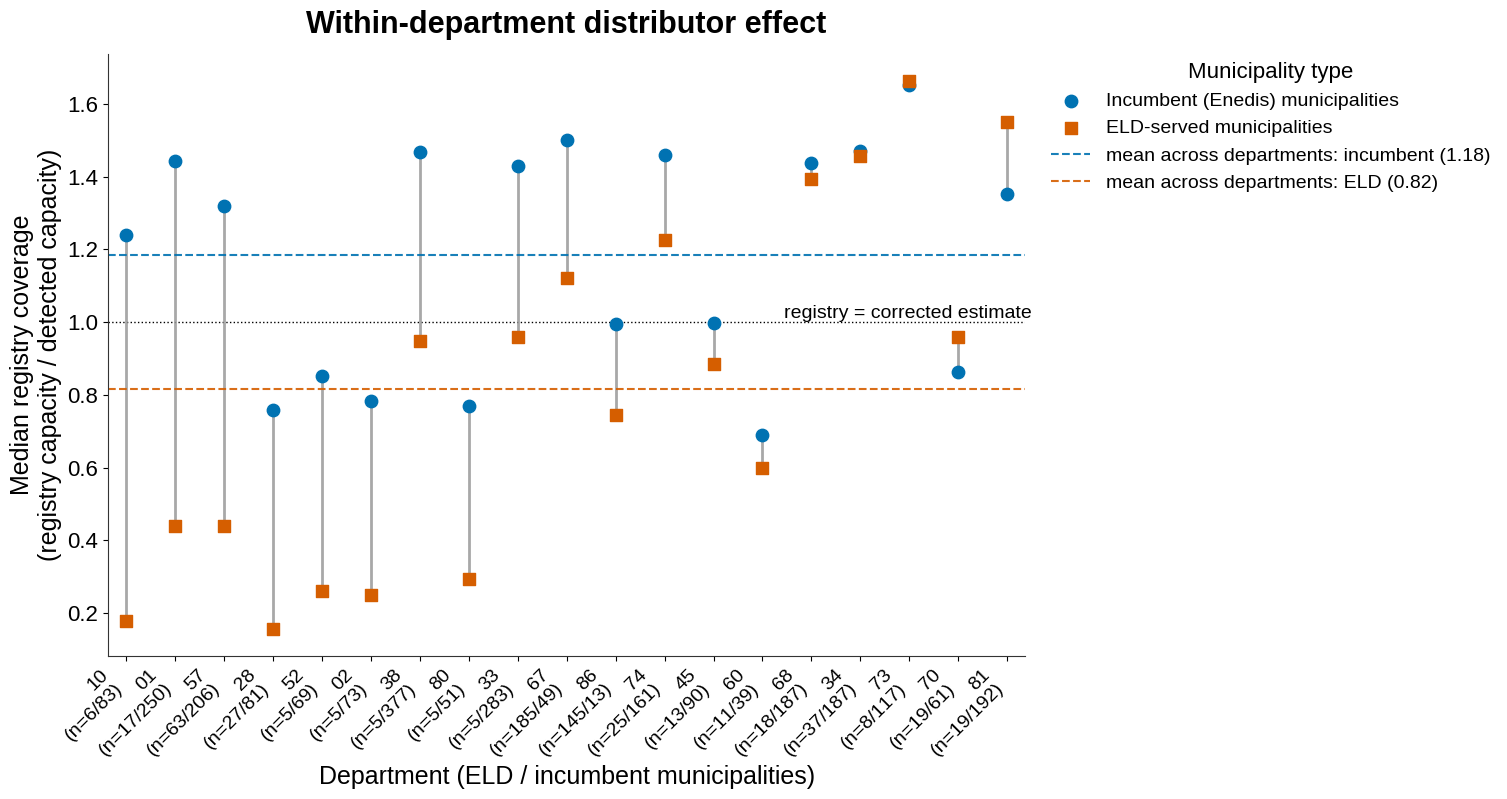

In [4]:
# --- Dumbbell figure, departments on the x axis ---

rows = []

for dpt, g in sub[sub.kWp_rte > 0].groupby('dpt'):
    eld, ene = g[g.is_eld == 1], g[g.is_eld == 0]
    if len(eld) >= 5 and len(ene) >= 5:
        rows.append({
            'dpt': dpt,
            'n_eld': len(eld),
            'n_ene': len(ene),
            'cov_eld': (eld.kWp_rte / eld.kWp_dpvm).median(),
            'cov_ene': (ene.kWp_rte / ene.kWp_dpvm).median()
        })

np_df = pd.DataFrame(rows)

np_df['diff_med'] = np_df.cov_eld - np_df.cov_ene
np_df = np_df.sort_values('diff_med').reset_index(drop=True)

w, wp = stats.wilcoxon(np_df['diff_med'])

neg = int((np_df.diff_med < 0).sum())

m_eld = np_df.cov_eld.mean()
m_ene = np_df.cov_ene.mean()


print(
    f"{len(np_df)} departments with at least 5 municipalities of each kind: "
    f"{neg}/{len(np_df)} show lower median coverage in ELD-served municipalities "
    f"(Wilcoxon p = {wp:.4f})"
)

print(
    f"mean of the medians: ELD {m_eld:.2f} | incumbent {m_ene:.2f} "
    f"(gap {100*(m_eld/m_ene-1):+.0f}%)"
)


# ---------------------------------------------------------
# Transposed figure
# ---------------------------------------------------------

C_ELD = style.OKABE_ITO['vermillion']
C_ENE = style.OKABE_ITO['blue']

x = np.arange(len(np_df))


fig, ax = plt.subplots(
    figsize=(max(16, 1.0 * len(np_df)), 8)
)


# ---------------------------------------------------------
# Reference line
# ---------------------------------------------------------

ax.axhline(
    1.0,
    color='black',
    lw=1,
    ls=':',
    zorder=1
)

ax.text(
    len(np_df)-0.5,
    1.0,
    'registry = corrected estimate',
    fontsize=14,
    color='black',
    va='bottom',
    ha='right'
)


# ---------------------------------------------------------
# Vertical dumbbell
# ---------------------------------------------------------

ax.vlines(
    x,
    np_df.cov_ene,
    np_df.cov_eld,
    color='#999999',
    lw=2,
    alpha=0.85,
    zorder=2
)


# Enedis
ax.scatter(
    x,
    np_df.cov_ene,
    s=80,
    color=C_ENE,
    zorder=3,
    label='Incumbent (Enedis) municipalities'
)


# ELD
ax.scatter(
    x,
    np_df.cov_eld,
    s=80,
    marker='s',
    color=C_ELD,
    zorder=3,
    label='ELD-served municipalities'
)


# ---------------------------------------------------------
# National means
# ---------------------------------------------------------

ax.axhline(
    m_ene,
    color=C_ENE,
    ls='--',
    lw=1.5,
    alpha=0.9,
    label=f'mean across departments: incumbent ({m_ene:.2f})'
)


ax.axhline(
    m_eld,
    color=C_ELD,
    ls='--',
    lw=1.5,
    alpha=0.9,
    label=f'mean across departments: ELD ({m_eld:.2f})'
)


# ---------------------------------------------------------
# Axes
# ---------------------------------------------------------

ax.set_xticks(x)

ax.set_xticklabels(
    [
        f"{r.dpt}\n(n={r.n_eld}/{r.n_ene})"
        for r in np_df.itertuples()
    ],
    fontsize=14,
    rotation=45,
    ha='right'
)


ax.set_ylabel(
    'Median registry coverage\n(registry capacity / detected capacity)',
    fontsize=18
)


ax.set_xlabel(
    'Department (ELD / incumbent municipalities)',
    fontsize=18
)


ax.set_title(
    'Within-department distributor effect',
    fontweight='bold',
    fontsize=22,
    pad=15
)


ax.tick_params(
    axis='y',
    labelsize=16
)


# ---------------------------------------------------------
# External legend
# ---------------------------------------------------------

ax.legend(
    fontsize=14,
    title='Municipality type',
    title_fontsize=16,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    framealpha=0.95,
    borderaxespad=0
)


ax.margins(x=0.02)


# room for the legend
plt.tight_layout(
    rect=[0, 0, 0.80, 1]
)


helpers.save_fig(
    fig,
    f'{FIG_PREFIX}_within_dept_effect_transposed.pdf',
    FIGS_DIR
)


plt.show()

## 3. By operator: the named local distributors against the incumbent, same departments

In [5]:
ops = []
for op, g in sub[(sub.is_eld == 1) & (sub.kWp_rte > 0)].groupby('gestionnaire'):
    if len(g) < 15:
        continue
    depts = g.dpt.unique()
    ref = sub[(sub.is_eld == 0) & (sub.kWp_rte > 0) & sub.dpt.isin(depts)]
    ops.append({'operateur': op, 'depts': ','.join(sorted(depts)[:4]), 'n_communes': len(g),
                'cov_mediane': (g.kWp_rte / g.kWp_dpvm).median(),
                'cov_mediane_enedis_memes_depts': (ref.kWp_rte / ref.kWp_dpvm).median() if len(ref) else np.nan})
ops = pd.DataFrame(ops).sort_values('cov_mediane')
ops['delta'] = ops.cov_mediane - ops.cov_mediane_enedis_memes_depts
print(ops.to_string(index=False, float_format=lambda v: f'{v:.2f}'))
print()
print("Two of these operators serve units of the hard core. One of their departments is served")
print("almost entirely by a single operator, so its identification comes from the fixed effects")
print("design rather than from a within-department comparison of its own.")

                                           operateur    depts  n_communes  cov_mediane  cov_mediane_enedis_memes_depts  delta
                                             Synelva       28          23         0.13                            0.76  -0.63
                              Régie Services Energie       01          17         0.44                            1.44  -1.00
                                              réséda       57          58         0.44                            1.32  -0.88
                                           SICAE Est 52,70,88          25         0.67                            1.05  -0.38
                                                 SRD    49,86         146         0.74                            1.07  -0.33
                                             EDF-SEI    2A,2B          27         0.84                             NaN    NaN
                                             GÉRÉDIS       79         135         0.89                            1.22

---

## 4. The econometric frame: identification, balance, inference

This section does not change the result of section 2. It makes it defensible. Four additions: an
explicit identifying assumption, a balance table, a ladder of controls, and inference that accounts
for the real number of clusters rather than the nominal one.

### 4.1 What is estimated, and under what assumption

The model, on municipalities where the detector finds at least `PV_FLOOR_KWC` of PV:

$$\log\left(\frac{\text{kWp}^{\text{registry}}_{i}}{\text{kWp}^{\text{detected}}_{i}}\right)
 = \beta\,\text{ELD}_i + \gamma' X_i + \delta_{d(i)} + \varepsilon_i$$

with $\delta_d$ a department fixed effect. Two properties of the design are worth stating
explicitly, because they are what make the estimate interpretable.

1. **The correction factor cancels exactly.** It is departmental, therefore constant within $d$.
   The raw registry-to-detections ratio suffices and no calibration enters $\beta$. This is the
   reason the test is run at the municipality rather than at the reporting unit: at the unit level
   the factor would not cancel and the estimate would inherit the calibration's uncertainty.
2. **The imagery year is absorbed.** It is constant within each department, verified below, so the
   fixed effect eliminates by construction the threat of a vintage mismatch between the two groups
   of municipalities.

**The identifying assumption.** Conditional on the department and the controls, ELD status
correlates with no other determinant of the registry-to-detections *ratio*.

The institutional argument that makes this plausible: the perimeter of the local distributors is a
legacy of the 1946 nationalisation, which exempted the utilities and cooperatives already in
existence. The assignment is eighty years old and unrelated to PV deployment in the 2020s, which
rules out reverse causation.

That is not random assignment, and the distinction is kept throughout: $\beta$ is a **conditional
association**, not a causal effect, and it is reported as one.

**The main threat, and its falsification.** If ELD-served municipalities were systematically less
well detected, the denominator would be understated and the ratio biased. Column (5) tests exactly
this, regressing detected capacity alone on the indicator.

Note the direction: such a bias would run *against* the result. An understated denominator inflates
the apparent coverage of ELD-served municipalities, so it would work to hide the effect rather than
to manufacture it.

**Selection on the denominator.** The floor conditions on detected capacity, and therefore on the
measurement error of the denominator. The sensitivity at 20 and 100 kWp bounds that effect.

In [6]:
# --- Estimator: fixed effects absorbed by within transformation, clustered errors ---
def within_ols_cluster(df, y, xs, fe='dpt', cluster='dpt'):
    """Beta, clustered SE and diagnostics for xs[0], with `fe` absorbed.

    The within transformation gives exactly the same coefficient and the same
    standard error as a dummy-variable regression with clustered errors, which is
    asserted below. It avoids rebuilding 96 dummies at every bootstrap
    replication, which is what makes the wild bootstrap affordable here.
    """
    cols = list(dict.fromkeys([y, *xs, fe, cluster]))
    d = df[cols].dropna().copy()
    g = d.groupby(fe)
    yv = (d[y].astype(float) - g[y].transform('mean')).to_numpy()
    X = np.column_stack([(d[c].astype(float) - g[c].transform('mean')).to_numpy() for c in xs])

    XtX_inv = np.linalg.inv(X.T @ X)
    b = XtX_inv @ (X.T @ yv)
    u = yv - X @ b

    n, k = X.shape
    n_fe = d[fe].nunique()
    codes = pd.factorize(d[cluster])[0]
    G = codes.max() + 1
    meat = np.zeros((k, k))
    for c in range(G):
        m = codes == c
        s = X[m].T @ u[m]
        meat += np.outer(s, s)
    dof = (G / (G - 1)) * ((n - 1) / (n - k - n_fe))
    V = XtX_inv @ meat @ XtX_inv * dof
    se = np.sqrt(np.diag(V))
    return dict(b=b, se=se, t=b / se, n=n, G=G, n_fe=n_fe,
                r2=1 - u.var() / yv.var(), X=X, y=yv, codes=codes)


def wild_cluster_p(res, B=999, seed=42):
    """Wild cluster bootstrap-t, Rademacher weights, null imposed on xs[0]
    (Cameron, Gelbach and Miller 2008).

    Why this is not cosmetic here. Clustered standard errors are asymptotic in the
    NUMBER OF CLUSTERS, not in the number of observations. Only departments
    containing both kinds of municipality carry information about beta, and there
    are 32 of them out of 96. At that count the clustered SE is biased downward
    and the asymptotic p-value is too optimistic. The bootstrap corrects it, and
    the correction is large enough to change what the paper can claim.
    """
    X, y, codes = res['X'], res['y'], res['codes']
    t_obs = res['t'][0]
    G, n, k = res['G'], res['n'], X.shape[1]

    # Restricted model, with the null imposed
    if k > 1:
        Xr = X[:, 1:]
        br = np.linalg.lstsq(Xr, y, rcond=None)[0]
        fit_r, u_r = Xr @ br, y - Xr @ br
    else:
        fit_r, u_r = np.zeros_like(y), y.copy()

    XtX_inv = np.linalg.inv(X.T @ X)
    dof = (G / (G - 1)) * ((n - 1) / (n - k - res['n_fe']))
    masks = [codes == c for c in range(G)]

    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(B):
        w = rng.choice([-1.0, 1.0], size=G)[codes]
        ys = fit_r + w * u_r
        bs = XtX_inv @ (X.T @ ys)
        us = ys - X @ bs
        meat = np.zeros((k, k))
        for m in masks:
            s = X[m].T @ us[m]
            meat += np.outer(s, s)
        V = XtX_inv @ meat @ XtX_inv * dof
        count += abs(bs[0] / np.sqrt(V[0, 0])) >= abs(t_obs)
    return (count + 1) / (B + 1)

In [7]:
# --- Sample, variables, and three structural checks -------------------------------
est = com[(com.kWp_dpvm >= PV_FLOOR_KWC) & com.is_eld.notna()].copy()
est['zero_rte'] = (est.kWp_rte == 0).astype(int)
est['log_dpvm'] = np.log(est.kWp_dpvm)
est['log_pop'] = np.log(est.population.clip(lower=1))
est_i = est[est.kWp_rte > 0].copy()
est_i['log_cov'] = np.log(est_i.kWp_rte / est_i.kWp_dpvm)

CTRL = ['log_dpvm', 'log_pop']

# (i) the within estimator reproduces the dummy-variable regression exactly
_sm = smf.ols('log_cov ~ is_eld + C(dpt)', data=est_i).fit(
    cov_type='cluster', cov_kwds={'groups': est_i['dpt']})
_wi = within_ols_cluster(est_i, 'log_cov', ['is_eld'])
assert abs(_sm.params['is_eld'] - _wi['b'][0]) < 1e-9
assert abs(_sm.bse['is_eld'] - _wi['se'][0]) < 1e-9
print(f"within vs dummy-variable regression: b = {_wi['b'][0]:+.4f}, SE = {_wi['se'][0]:.4f}   OK")

# (ii) is the imagery year constant within a department?
_nu = est.groupby('dpt')['year'].nunique()
print(f"departments with a single imagery year: {(_nu == 1).sum()} / {len(_nu)} "
      f"-> vintage absorbed by the fixed effects")

# (iii) how many clusters actually carry information about beta?
_g = est.groupby('dpt')['is_eld'].agg(['size', 'sum'])
_ident = _g[(_g['sum'] > 0) & (_g['sum'] < _g['size'])]
print(f"departments with variation in operator type (identifying clusters): {len(_ident)} / {len(_g)}")
print(f"sample: {len(est):,} municipalities ({int(est.is_eld.sum())} ELD-served), of which "
      f"{len(est_i):,} carry a strictly positive registry capacity")

within vs dummy-variable regression: b = -0.5380, SE = 0.1331   OK
departments with a single imagery year: 96 / 96 -> vintage absorbed by the fixed effects
departments with variation in operator type (identifying clusters): 32 / 96
sample: 14,551 municipalities (817 ELD-served), of which 14,500 carry a strictly positive registry capacity


### 4.2 Balance table

Do ELD-served municipalities resemble the incumbent-served ones of the same department? The
normalised difference is the Imbens-Rubin statistic; beyond 0.25 in absolute value, imbalance is
generally judged problematic. The within difference is conditional on the fixed effects, with its
bootstrapped p-value.

The table is here to be read against the conclusion, not to decorate it: an imbalance that the
controls do not absorb is a limitation of the estimate and is reported as such in 4.4.

In [8]:
BALANCE = [('population', 'Population'),
           ('kWp_dpvm', 'Detected capacity (kWp)'),
           ('n_installations_dpvm', 'Detected arrays'),
           ('log_pop', 'log population'),
           ('log_dpvm', 'log detected capacity')]

rows = []
for col, lab in BALANCE:
    e, i = est.loc[est.is_eld == 1, col], est.loc[est.is_eld == 0, col]
    r = within_ols_cluster(est, col, ['is_eld'])
    rows.append({'variable': lab, 'ELD': e.mean(), 'Incumbent': i.mean(),
                 'norm. diff.': (e.mean() - i.mean()) / np.sqrt((e.var() + i.var()) / 2),
                 'within diff.': r['b'][0], 'SE': r['se'][0],
                 'p (wild)': wild_cluster_p(r, B=299)})

balance = pd.DataFrame(rows)
balance.to_csv(paths.ELD_BALANCE, index=False)
print(balance.round(3).to_string(index=False))

               variable      ELD  Incumbent  norm. diff.  within diff.      SE  p (wild)
             Population 2200.151   3906.616       -0.102     -1229.976 563.461     0.040
Detected capacity (kWp)  150.783    187.702       -0.161       -27.535  12.224     0.023
        Detected arrays   24.228     34.904       -0.255        -7.423   3.295     0.033
         log population    7.042      7.170       -0.108        -0.244   0.172     0.210
  log detected capacity    4.769      4.873       -0.150        -0.074   0.041     0.087


### 4.3 Regression table

Five specifications. (1) and (2) are the intensive margin, without and with controls. (3) and (4)
are the extensive margin, as a linear probability model: a fixed-effects logit would suffer from
the incidental parameters problem with 96 groups.

(5) is the falsification test. If detected capacity does not differ between the two kinds of
municipality within a department, then the coverage gap cannot be an artefact of detection. A
specification that can only confirm is not worth running; this one can fail.

In [9]:
SPECS = [
    ('(1)', est_i, 'log_cov', ['is_eld'], 'log coverage', False),
    ('(2)', est_i, 'log_cov', ['is_eld', *CTRL], 'log coverage', True),
    ('(3)', est, 'zero_rte', ['is_eld'], 'P(no registry record)', False),
    ('(4)', est, 'zero_rte', ['is_eld', *CTRL], 'P(no registry record)', True),
    ('(5)', est, 'log_dpvm', ['is_eld', 'log_pop'], 'log detected capacity', True),
]

res_rows = []
for tag, df, y, xs, lab, has_ctrl in SPECS:
    r = within_ols_cluster(df, y, xs)
    res_rows.append({'spec': tag, 'outcome': lab, 'beta': r['b'][0], 'SE': r['se'][0],
                     't': r['t'][0], 'p (wild)': wild_cluster_p(r),
                     'implied %': np.nan if y == 'zero_rte' else 100 * (np.exp(r['b'][0]) - 1),
                     'pp': 100 * r['b'][0] if y == 'zero_rte' else np.nan,
                     'controls': has_ctrl, 'N': r['n'], 'clusters': r['G'],
                     'R2 within': r['r2']})

reg = pd.DataFrame(res_rows)
reg.to_csv(paths.ELD_REGRESSION, index=False)
with pd.option_context('display.width', 220):
    print(reg.round(4).to_string(index=False))

_e = est.loc[est.is_eld == 1, 'zero_rte']
_i = est.loc[est.is_eld == 0, 'zero_rte']
print(f"\nraw rates, P(no registry record): ELD {_e.mean():.2%} "
      f"({int(_e.sum())} of {len(_e)} municipalities) vs incumbent {_i.mean():.2%} "
      f"-> raw ratio {_e.mean() / _i.mean():.1f}x")

spec               outcome    beta     SE       t  p (wild)  implied %     pp  controls     N  clusters  R2 within
 (1)          log coverage -0.5380 0.1331 -4.0409     0.001   -41.6106    NaN     False 14500        96     0.0191
 (2)          log coverage -0.4821 0.1619 -2.9780     0.011   -38.2501    NaN      True 14500        96     0.2728
 (3) P(no registry record)  0.0362 0.0195  1.8537     0.123        NaN 3.6172     False 14551        96     0.0087
 (4) P(no registry record)  0.0355 0.0195  1.8246     0.123        NaN 3.5537      True 14551        96     0.0109
 (5) log detected capacity  0.0295 0.0530  0.5564     0.607     2.9904    NaN      True 14551        96     0.4870

raw rates, P(no registry record): ELD 2.20% (18 of 817 municipalities) vs incumbent 0.24% -> raw ratio 9.2x


In [10]:
# --- tabular LaTeX pret a coller ---------------------------------------------------
def _f(v, d=3):
    return f"{v:.{d}f}"

lines = [
    r"\begin{tabular}{lccccc}", r"\toprule",
    r" & \multicolumn{2}{c}{log registry coverage} & \multicolumn{2}{c}{no registry record}"
    r" & falsification \\",
    r"\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-6}",
    r" & (1) & (2) & (3) & (4) & (5) \\", r"\midrule",
    r"ELD municipality & " + " & ".join(_f(v) for v in reg['beta']) + r" \\",
    r" & " + " & ".join(f"({_f(v)})" for v in reg['SE']) + r" \\",
    r" & " + " & ".join(f"[{_f(v)}]" for v in reg['p (wild)']) + r" \\",
    r"\midrule",
    r"Department fixed effects & Yes & Yes & Yes & Yes & Yes \\",
    r"Controls & " + " & ".join('Yes' if v else 'No' for v in reg['controls']) + r" \\",
    r"Observations & " + " & ".join(f"{int(v):,}" for v in reg['N']) + r" \\",
    r"Clusters (departments) & " + " & ".join(str(int(v)) for v in reg['clusters']) + r" \\",
    r"Within $R^2$ & " + " & ".join(_f(v) for v in reg['R2 within']) + r" \\",
    r"\bottomrule", r"\end{tabular}",
]
print("\n".join(lines))

\begin{tabular}{lccccc}
\toprule
 & \multicolumn{2}{c}{log registry coverage} & \multicolumn{2}{c}{no registry record} & falsification \\
\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-6}
 & (1) & (2) & (3) & (4) & (5) \\
\midrule
ELD municipality & -0.538 & -0.482 & 0.036 & 0.036 & 0.029 \\
 & (0.133) & (0.162) & (0.020) & (0.019) & (0.053) \\
 & [0.001] & [0.011] & [0.123] & [0.123] & [0.607] \\
\midrule
Department fixed effects & Yes & Yes & Yes & Yes & Yes \\
Controls & No & Yes & No & Yes & Yes \\
Observations & 14,500 & 14,500 & 14,551 & 14,551 & 14,551 \\
Clusters (departments) & 96 & 96 & 96 & 96 & 96 \\
Within $R^2$ & 0.019 & 0.273 & 0.009 & 0.011 & 0.487 \\
\bottomrule
\end{tabular}


### 4.4 Reading

**Established.** The coverage effect holds. The coefficient moves from $-0.54$ to $-0.48$ when the
controls are added, an implied gap of $-42\%$ to $-38\%$, and it stays significant under the wild
bootstrap.

The falsification comes out clean: detected capacity does not differ between the two kinds of
municipality within a department. The coverage gap is therefore not a detection artefact, which
turns an assumption the main text was making into something tested.

**Two numbers that do not survive as stated.** Both are worth correcting rather than defending.

The $p$-value on the intensive margin is not $10^{-4}$ but of order $10^{-3}$ once bootstrapped.
The conclusion is unaffected, but the $10^{-4}$ is an artefact of cluster asymptotics at 32
identifying clusters, and reporting it would be reporting the bias rather than the estimate.

The claim that ELD-served municipalities are "ten times more likely" to carry no registry record is
a ratio of raw rates, 2.2% against 0.24%, and it rests on **18 municipalities**. Conditional on the
department the gap is about $+2$ percentage points with a bootstrapped $p$ around 0.12:
directionally consistent, statistically unresolved. It should be presented that way.

**Not established, and stated as such.** $\beta$ remains a conditional association. ELD-served
municipalities are smaller on average, which the balance table shows and which the controls absorb
only in part. The 1946 legacy rules out reverse causation; it does not establish exogeneity.

### 4.5 Sensitivity to the detection floor

The floor conditions on detected capacity, and therefore on the measurement error of the
denominator, and its level is an analyst's choice. The whole apparatus is therefore re-run at 20,
50 and 100 kWp: intensive margin without and with controls, extensive margin, and the departmental
Wilcoxon test.

Moving from 20 to 100 kWp divides the sample by nearly three, which is enough on its own to explain
any widening of the intervals. Keeping that in view is what separates a loss of power from a
reversal.

In [11]:
FLOORS = (20, 50, 100)
rows = []

for floor in FLOORS:
    e = com[(com.kWp_dpvm >= floor) & com.is_eld.notna()].copy()
    e['zero_rte'] = (e.kWp_rte == 0).astype(int)
    e['log_dpvm'] = np.log(e.kWp_dpvm)
    e['log_pop'] = np.log(e.population.clip(lower=1))
    ei = e[e.kWp_rte > 0].copy()
    ei['log_cov'] = np.log(ei.kWp_rte / ei.kWp_dpvm)

    r_base = within_ols_cluster(ei, 'log_cov', ['is_eld'])
    r_ctrl = within_ols_cluster(ei, 'log_cov', ['is_eld', 'log_dpvm', 'log_pop'])
    r_ext = within_ols_cluster(e, 'zero_rte', ['is_eld', 'log_dpvm', 'log_pop'])

    # Departmental Wilcoxon, same criteria as section 2: at least 5 municipalities per group
    diffs = []
    for _, g in ei.groupby('dpt'):
        a, b = g[g.is_eld == 1], g[g.is_eld == 0]
        if len(a) >= 5 and len(b) >= 5:
            diffs.append((a.kWp_rte / a.kWp_dpvm).median() - (b.kWp_rte / b.kWp_dpvm).median())
    _, p_w = stats.wilcoxon(diffs)

    rows.append({
        'floor (kWp)': floor, 'N': len(e), 'N ELD': int(e.is_eld.sum()),
        'beta': r_base['b'][0], 'SE': r_base['se'][0], 'p (wild)': wild_cluster_p(r_base),
        'implied %': 100 * (np.exp(r_base['b'][0]) - 1),
        'beta (ctrl)': r_ctrl['b'][0], 'p ctrl': wild_cluster_p(r_ctrl),
        'extensive (pp)': 100 * r_ext['b'][0], 'p ext': wild_cluster_p(r_ext),
        'Wilcoxon neg/n': f"{sum(1 for x in diffs if x < 0)}/{len(diffs)}",
        'p Wilcoxon': p_w,
    })

floors = pd.DataFrame(rows)
floors.to_csv(paths.ELD_FLOOR_SENSITIVITY, index=False)
with pd.option_context('display.width', 220):
    print(floors.round(4).to_string(index=False))

 floor (kWp)     N  N ELD    beta     SE  p (wild)  implied %  beta (ctrl)  p ctrl  extensive (pp)  p ext Wilcoxon neg/n  p Wilcoxon
          20 22536   1296 -0.4756 0.1174     0.001   -37.8492      -0.4369   0.007          3.5424  0.111          19/22      0.0000
          50 14551    817 -0.5380 0.1331     0.001   -41.6106      -0.4821   0.011          3.5537  0.123          16/19      0.0003
         100  8168    420 -0.4479 0.1375     0.002   -36.1035      -0.4031   0.066          3.1871  0.093            8/9      0.0117


**Reading.** The intensive estimate stays between $-0.48$ and $-0.40$ depending on the floor and
on the presence of controls, an implied gap of $-36\%$ to $-42\%$, and the sign never changes. The
departmental Wilcoxon rejects at all three floors, on a number of paired departments that falls
from 22 to 9.

The extensive margin is resolved at none of them, which confirms it should be presented as
directional rather than established. That is the same conclusion 4.4 reaches from a different
direction, and the agreement between the two is worth more than either alone.

One point to state plainly rather than bury: with controls at the 100 kWp floor, $p = 0.07$. The
sample is then nearly three times smaller than at 20 kWp while the point estimate barely moves,
$-0.40$ against $-0.44$. That is a loss of power, not a reversal.